# 06 — PCA clock on cluster-level methylation

Alternative to the regression-on-CpGs clock in `05_network_clock_v2.ipynb`.

**Pipeline:**
1. For each network cluster, build one *cluster methylation variable*:
   - Singletons → the CpG's methylation directly.
   - Small clusters (`< BIG_CLUSTER_THRESHOLD` CpGs) → mean methylation across CpGs.
   - Big clusters (`>= BIG_CLUSTER_THRESHOLD` CpGs) → mean methylation **only if** the across-sample distribution is bell-shaped. If any big cluster fails the bell-shape check, execution pauses.
2. Standardise the cluster matrix on the training fold.
3. Fit PCA on the training fold.
4. Sweep over top-K PCs (K ∈ {10, 20, …, 100}); fit Ridge on each top-K block.
5. Save a portable clock dict so the same clock can be applied to a new methylation dataset.

**Why Ridge over OLS on PC scores:** PCA scores are uncorrelated by construction, but the *variance* of each PC drops fast. OLS gives equal-status coefficients to high-variance and tiny low-variance PCs, so the trailing PCs (with high noise-to-signal) inflate the fit. Ridge shrinks each PC's coefficient by roughly `1/(λᵢ + α)` where `λᵢ` is the PC's variance — i.e. it down-weights the noisy tail PCs automatically. With `RidgeCV` the L2 strength is picked via CV on the training fold.

**Output for portability:** `outputs/06_pca_clock/saved_clocks/pca_clock.pkl` contains cluster definitions, scaler params, PCA loadings, and per-K ridge coefficients. A `predict_pca_clock(df_meth_new, clock, K)` function is defined at the end to apply it to new data.

In [1]:
import os, warnings, pickle, json
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────────
FILTERED_BETAS = "outputs/01_filtered_betas/BetaMatrix_0.35.tsv"
SAMPLESHEET    = "outputs/01_filtered_betas/Samplesheet.csv"
MODULE_CSV     = "outputs/02_network/module_assignments_0.70.csv"

# Whole (unfiltered) probe matrix — CpGs × samples, ~12.6 GB. Same samples as the
# filtered matrix above. ADJUST THIS PATH to your layout if needed.
BETA_ALL_TSV   = "../data/raw/WB_PB_BC_PBL/Beta_ALL.tsv"

# ── Cluster-level methylation strategy ───────────────────────────
BIG_CLUSTER_THRESHOLD = 10           # clusters with >= this many CpGs trigger the bell-shape check

# Bell-shape thresholds for the cluster-mean distribution across samples
SKEW_MAX        = 1.0                # |skew| < this counts as bell-shaped
EXCESS_KURT_MIN = -1.5
EXCESS_KURT_MAX = 3.0
BIMODALITY_MAX  = 5/9                # Sarle's coefficient: > 5/9 suggests bimodality

# ── PCA + regression parameters ──────────────────────────────────
PC_COUNTS_TO_TEST    = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
MAX_PCA_COMPONENTS   = max(PC_COUNTS_TO_TEST) + 5    # fit once, slice per K
USE_RIDGE            = True                          # set False for plain OLS on PCs
RIDGE_ALPHAS         = np.logspace(-3, 3, 25)
RIDGE_CV_FOLDS       = 5

# ── Split ────────────────────────────────────────────────────────
TEST_FRACTION = 0.2
SEED          = 42

# ── Output directories ───────────────────────────────────────────
OUT_DIR          = Path("outputs/05_pca_clock")
OUT_DIR.mkdir(parents=True, exist_ok=True)
SAVED_CLOCKS_DIR = OUT_DIR / "saved_clocks"
SAVED_CLOCKS_DIR.mkdir(parents=True, exist_ok=True)

# Cache for the streamed whole-array matrix (samples × all CpGs) so the heavy
# 12.6 GB read happens only once.
ARRAY_CACHE = OUT_DIR / "cache_beta_all_train.npz"

# ── Plot style (matches 05_network_clock_v2.ipynb) ───────────────
DPI = 300
mpl.rcParams.update({
    "font.family": "Arial", "font.size": 12,
    "axes.labelsize": 12, "figure.dpi": DPI, "savefig.dpi": DPI,
    "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def _save(fig, path):
    p = Path(path)
    fig.savefig(str(p), dpi=DPI)
    fig.savefig(str(p.with_suffix(".svg")))
    print(f"  -> {p}")

STUDY_PALETTE = ["#4477AA","#EE6677","#228833","#CCBB44","#66CCEE",
                 "#AA3377","#BBBBBB","#E69F00","#56B4E9","#009E73",
                 "#D55E00","#CC79A7","#0072B2","#F0E442","#882255"]


## 1. Data loader (shared with 05)

In [2]:
def load_methylation(beta_path, sheet_path):
    """Load methylation matrix with Sample × CpG layout, plus aligned metadata.
    Returns (df_meth indexed by Sample_ID, meta DataFrame with Age + Study_ID).
    Identical to the loader used in 05_network_clock_v2.ipynb so the same
    inputs work here without modification."""
    print(f"Loading {beta_path} ...")
    df = pd.read_csv(beta_path, sep="\t", low_memory=False)

    cpg_cols = [c for c in df.columns if str(c).startswith("cg")]
    if not cpg_cols:
        fc = df.columns[0]
        if df[fc].astype(str).head(20).str.startswith("cg").sum() > 10:
            df = df.set_index(fc).T.reset_index()
            df.rename(columns={df.columns[0]: "Sample_ID"}, inplace=True)
        cpg_cols = [c for c in df.columns if str(c).startswith("cg")]

    idc = next((c for c in ["Sample_ID", "ID_REF", "ID", "Sample", "geo_accession"]
                if c in df.columns), None)
    df_meth = df[cpg_cols].apply(pd.to_numeric, errors="coerce")
    if idc:
        df_meth.index = df[idc].astype(str)

    meta = pd.read_csv(sheet_path)
    for c in meta.columns:
        if c.lower() == "age":
            meta = meta.rename(columns={c: "Age"})
    meta["Age"] = pd.to_numeric(meta["Age"], errors="coerce")

    mid = next((c for c in ["Sample_ID", "ID_REF", "ID", "Sample", "geo_accession"]
                if c in meta.columns), None)
    if mid:
        meta = meta.set_index(meta[mid].astype(str))
    common = df_meth.index.intersection(meta.index)
    df_meth = df_meth.loc[common]
    meta = meta.loc[common]

    if "Study_ID" not in meta.columns:
        for alt in ["GSE", "Study", "Series", "Dataset"]:
            if alt in meta.columns:
                meta = meta.rename(columns={alt: "Study_ID"})
                break
        if "Study_ID" not in meta.columns:
            meta["Study_ID"] = "unknown"

    print(f"  Loaded: {df_meth.shape[0]} samples × {df_meth.shape[1]:,} CpGs")
    print(f"  Studies: {meta['Study_ID'].value_counts().to_dict()}")
    return df_meth, meta


def load_whole_array_for_samples(beta_all_path, sample_index, cache_path=None,
                                 sep="\t", dtype_float="float32", chunksize=20000):
    """Load the huge Beta_ALL.tsv (CpGs × samples), keeping only the columns for
    `sample_index`, returned as a samples × CpGs DataFrame aligned to that index.

    Streams the file in CpG-row chunks so peak memory stays near the size of the
    final matrix (~2.6 GB for ~1900 samples × ~337k CpGs in float32), never the
    full 12.6 GB. Caches the result to parquet (atomic write) for instant reuse.
    """
    sample_index = pd.Index(sample_index).astype(str)

    if cache_path is not None and Path(cache_path).exists():
        print(f"  Loading cached whole-array matrix → {cache_path}")
        try:
            z = np.load(cache_path, allow_pickle=True)
            df_all = pd.DataFrame(z["values"],
                                  index=z["index"].astype(str),
                                  columns=z["columns"].astype(str))
            return df_all.reindex(sample_index)
        except Exception as e:
            print(f"    cache unreadable ({type(e).__name__}) — re-streaming")
            Path(cache_path).unlink(missing_ok=True)

    print(f"  Streaming {beta_all_path} (all CpGs, training-sample columns only) ...")
    header = pd.read_csv(beta_all_path, sep=sep, nrows=0)
    cpg_col = header.columns[0]
    file_samples = set(str(c) for c in header.columns[1:])
    wanted = [s for s in sample_index if s in file_samples]
    missing = [s for s in sample_index if s not in file_samples]
    print(f"    {len(wanted)}/{len(sample_index)} training samples present in Beta_ALL"
          + (f"  ({len(missing)} missing)" if missing else ""))
    if not wanted:
        raise ValueError("No training samples matched Beta_ALL columns — check IDs. "
                         f"Beta_ALL columns look like: {list(header.columns[1:4])}")

    usecols = [cpg_col] + wanted
    parts, n_rows = [], 0
    for chunk in pd.read_csv(beta_all_path, sep=sep, usecols=usecols,
                             index_col=0, chunksize=chunksize, low_memory=False):
        parts.append(chunk.astype(dtype_float))
        n_rows += chunk.shape[0]
        print(f"      ... {n_rows:,} CpGs read", end="\r")
    df_cpg_by_sample = pd.concat(parts); del parts
    print(f"\n    loaded {df_cpg_by_sample.shape[0]:,} CpGs × {df_cpg_by_sample.shape[1]:,} samples")

    df_all = df_cpg_by_sample.T; del df_cpg_by_sample      # → samples × CpGs
    df_all.index = df_all.index.astype(str)

    if cache_path is not None:
        tmp = Path(str(cache_path) + ".tmp.npz")
        np.savez(tmp, values=df_all.values.astype(dtype_float),
                 index=np.asarray(df_all.index, dtype=object),
                 columns=np.asarray(df_all.columns, dtype=object))
        tmp.replace(cache_path)                            # atomic: never half-written
        print(f"    cached → {cache_path}")

    return df_all.reindex(sample_index)


In [3]:
df_meth, meta = load_methylation(FILTERED_BETAS, SAMPLESHEET)
ages      = meta["Age"].values
study_ids = meta["Study_ID"].values

module_dict = pd.read_csv(MODULE_CSV).set_index("CpG")["Module"].to_dict()
print(f"  Modules: {len(set(module_dict.values()))} unique")


Loading outputs/01_filtered_betas/BetaMatrix_0.35.tsv ...
  Loaded: 1917 samples × 7,328 CpGs
  Studies: {'GSE87571': 664, 'GSE51032': 424, 'GSE125105': 210, 'GSE42861': 209, 'GSE61496': 150, 'GSE59065': 97, 'GSE87648': 73, 'GSE81961': 25, 'E_MTAB_4931': 24, 'GSE99624': 16, 'GSE87640': 13, 'GSE107737': 12}
  Modules: 4595 unique


## 2. Cluster-level methylation variables + bell-shape check

For each module we build a single across-CpG variable per sample. Singletons and small clusters get the mean (trivially OK). For big clusters (≥ `BIG_CLUSTER_THRESHOLD` CpGs) the mean only makes sense if the resulting per-sample distribution is approximately bell-shaped — otherwise the average is collapsing genuinely multi-modal biology into a misleading single number, and we should stop and discuss an alternative (e.g. per-CpG, median split, separate sub-cluster averages, …).

In [4]:
def is_bell_shaped(x,
                   skew_max=SKEW_MAX,
                   ek_min=EXCESS_KURT_MIN, ek_max=EXCESS_KURT_MAX,
                   bc_max=BIMODALITY_MAX):
    """Return (bell, diag_dict) for a 1-D distribution.
    'Bell-shaped' = bounded skew, bounded excess kurtosis, and Sarle's
    bimodality coefficient below the bimodality cutoff (5/9 by convention)."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 30:
        return False, {"reason": "too few samples", "n": n}
    sk = float(skew(x))
    ku = float(kurtosis(x, fisher=True))   # excess kurtosis
    # Sarle's bimodality coefficient (small-n corrected denominator)
    if n > 3:
        denom = ku + 3*(n-1)**2 / ((n-2)*(n-3))
        bc = (sk**2 + 1) / denom if denom > 0 else np.inf
    else:
        bc = np.inf
    skew_ok = abs(sk) < skew_max
    kurt_ok = ek_min < ku < ek_max
    bc_ok   = bc < bc_max
    return (skew_ok and kurt_ok and bc_ok), {
        "n": n, "skew": sk, "kurtosis": ku, "bimodality_coef": bc,
        "skew_ok": skew_ok, "kurt_ok": kurt_ok, "bc_ok": bc_ok,
    }

# Group CpGs by cluster (only CpGs that survive filtering)
cluster_cpgs = defaultdict(list)
for cpg, m in module_dict.items():
    if cpg in df_meth.columns:
        cluster_cpgs[m].append(cpg)

# Classify by size
singletons = {m: cpgs for m, cpgs in cluster_cpgs.items() if len(cpgs) == 1}
small      = {m: cpgs for m, cpgs in cluster_cpgs.items()
              if 2 <= len(cpgs) < BIG_CLUSTER_THRESHOLD}
big        = {m: cpgs for m, cpgs in cluster_cpgs.items()
              if len(cpgs) >= BIG_CLUSTER_THRESHOLD}

print(f"  Cluster size summary:")
print(f"    Singletons (1 CpG):                       {len(singletons):5d}")
print(f"    Small (2-{BIG_CLUSTER_THRESHOLD-1} CpGs, no bell check):      {len(small):5d}")
print(f"    Big  (>= {BIG_CLUSTER_THRESHOLD} CpGs, bell-checked):        {len(big):5d}")
print(f"    TOTAL clusters used as variables:         {len(cluster_cpgs):5d}")


  Cluster size summary:
    Singletons (1 CpG):                        4351
    Small (2-9 CpGs, no bell check):        235
    Big  (>= 10 CpGs, bell-checked):            9
    TOTAL clusters used as variables:          4595


  Bell-shape check on 9 big clusters: 6 pass, 3 fail


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  -> outputs/05_pca_clock/big_cluster_distributions.pdf


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

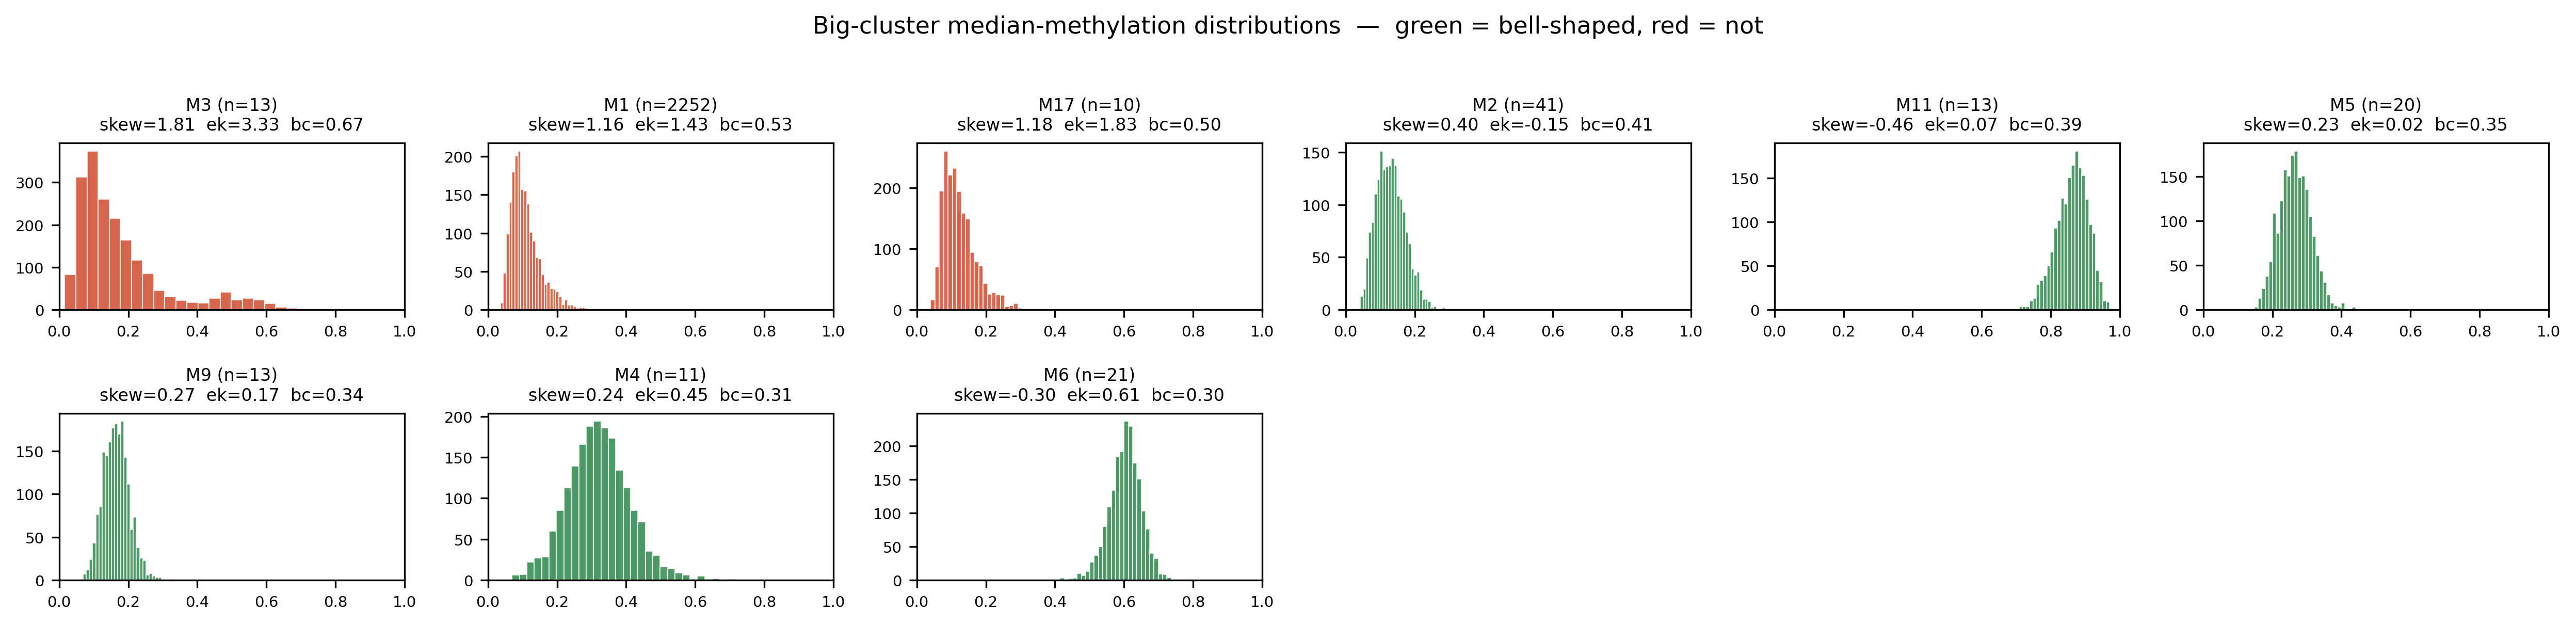

  Saved diagnostics → outputs/05_pca_clock/big_cluster_bellcheck.csv


RuntimeError: 
3 big cluster(s) failed the bell-shape check. PAUSING — let's discuss the representation for these before continuing.

Failed clusters (top 20):
 cluster  n_cpgs     skew  kurtosis  bimodality_coef
       3      13 1.805033  3.332059         0.671975
       1    2252 1.155346  1.431001         0.526371
      17      10 1.182835  1.831177         0.496104

Options to consider:
  - Use the PageRank-central CpG (like 05's top-modules method) instead of the mean
  - Split the cluster into sub-modes (e.g. k-means k=2 on the per-CpG mean) and treat each as a separate variable
  - Use the median instead of the mean
  - Drop the cluster
  - Loosen the bell-shape thresholds (SKEW_MAX, BIMODALITY_MAX) if the failures are borderline

In [5]:
# Compute median methylation across CpGs for each big cluster, run bell-shape test
big_cluster_meth = {}
big_cluster_rows = []
for m, cpgs in big.items():
    series = df_meth[cpgs].median(axis=1)      # median across CpGs in the cluster, per sample
    bell, diag = is_bell_shaped(series.values)
    big_cluster_meth[m] = series
    big_cluster_rows.append({"cluster": m, "n_cpgs": len(cpgs),
                             "bell": bell, **diag})

df_big = (pd.DataFrame(big_cluster_rows)
          .sort_values(["bell", "bimodality_coef"], ascending=[True, False])
          .reset_index(drop=True))
n_big    = len(df_big)
n_failed = int((~df_big["bell"]).sum())
n_passed = int(df_big["bell"].sum())
print(f"  Bell-shape check on {n_big} big clusters: {n_passed} pass, {n_failed} fail")

# Plot all (or top N worst) big-cluster distributions; red = failed, green = passed
MAX_PLOT = 60
to_plot = df_big.head(MAX_PLOT) if n_big > MAX_PLOT else df_big
if n_big > MAX_PLOT:
    print(f"  Plotting first {MAX_PLOT} (worst-first); full results in CSV")

if len(to_plot) > 0:
    ncols = 6
    nrows = int(np.ceil(len(to_plot) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.8 * ncols, 2.0 * nrows), squeeze=False)
    for ax, (_, row) in zip(axes.flat, to_plot.iterrows()):
        m = row["cluster"]
        series = big_cluster_meth[m]
        color = "#117733" if row["bell"] else "#CC3311"
        ax.hist(series.dropna().values, bins=30, color=color, alpha=0.75,
                edgecolor="white", linewidth=0.5)
        ax.set_title(f"M{m} (n={row['n_cpgs']})\n"
                     f"skew={row['skew']:.2f}  ek={row['kurtosis']:.2f}  bc={row['bimodality_coef']:.2f}",
                     fontsize=8)
        ax.set_xlim(0, 1); ax.tick_params(labelsize=7)
    for ax in axes.flat[len(to_plot):]:
        ax.axis("off")
    fig.suptitle("Big-cluster median-methylation distributions  —  green = bell-shaped, red = not",
                 y=1.005, fontsize=11)
    fig.tight_layout()
    _save(fig, OUT_DIR / "big_cluster_distributions.pdf")
    plt.show()
else:
    print("  No big clusters to plot.")

# Save the full diagnostic CSV regardless
df_big.to_csv(OUT_DIR / "big_cluster_bellcheck.csv", index=False)
print(f"  Saved diagnostics → {OUT_DIR / 'big_cluster_bellcheck.csv'}")

# Pause if anything failed — discuss the representation before continuing
if n_failed > 0:
    failed = df_big[~df_big["bell"]][["cluster", "n_cpgs", "skew", "kurtosis", "bimodality_coef"]]
    msg = (f"\n{n_failed} big cluster(s) failed the bell-shape check. "
           f"PAUSING — let's discuss the representation for these before continuing.\n\n"
           f"Failed clusters (top 20):\n{failed.head(20).to_string(index=False)}\n\n"
           f"Options to consider:\n"
           f"  - Use the PageRank-central CpG (like 05's top-modules method) instead of the mean\n"
           f"  - Split the cluster into sub-modes (e.g. k-means k=2 on the per-CpG mean) and treat each as a separate variable\n"
           f"  - Use the median instead of the mean\n"
           f"  - Drop the cluster\n"
           f"  - Loosen the bell-shape thresholds (SKEW_MAX, BIMODALITY_MAX) if the failures are borderline")
    raise RuntimeError(msg)

print("\n✓ All big clusters are bell-shaped — proceeding with cluster-median methylation.")


## 3. Assemble the Sample × Cluster matrix

In [6]:
# Build Sample × Cluster matrix. Record per-cluster strategy so the saved clock
# can rebuild this matrix on new data with the same recipe.
cluster_strategy = {}            # cluster_id -> {"cpgs": [...], "strategy": "singleton"|"median"}
cols = {}
for m, cpgs in cluster_cpgs.items():
    if len(cpgs) == 1:
        cluster_strategy[m] = {"cpgs": cpgs, "strategy": "singleton"}
        cols[m] = df_meth[cpgs[0]]
    else:
        cluster_strategy[m] = {"cpgs": cpgs, "strategy": "median"}
        cols[m] = df_meth[cpgs].median(axis=1)

X_clusters = pd.DataFrame(cols)
# Stable, deterministic column order: sort cluster IDs
X_clusters = X_clusters[sorted(X_clusters.columns)]
print(f"  Cluster matrix: {X_clusters.shape[0]} samples × {X_clusters.shape[1]} cluster variables")

# Fill any residual NaNs with column means (rare after the cluster-level averaging)
nan_count = int(X_clusters.isna().sum().sum())
if nan_count:
    print(f"  Filling {nan_count} NaN entries with column means")
    X_clusters = X_clusters.fillna(X_clusters.mean())


  Cluster matrix: 1917 samples × 4595 cluster variables


## 4. Train/test split

In [7]:
idx = np.arange(len(ages))
i_tr, i_te = train_test_split(idx, test_size=TEST_FRACTION, random_state=SEED)
print(f"  Train: n={len(i_tr)} | Test: n={len(i_te)}")
print(f"  Train studies: {sorted(set(np.array(study_ids)[i_tr]))}")
print(f"  Test  studies: {sorted(set(np.array(study_ids)[i_te]))}")


  Train: n=1533 | Test: n=384
  Train studies: ['E_MTAB_4931', 'GSE107737', 'GSE125105', 'GSE42861', 'GSE51032', 'GSE59065', 'GSE61496', 'GSE81961', 'GSE87571', 'GSE87640', 'GSE87648', 'GSE99624']
  Test  studies: ['E_MTAB_4931', 'GSE107737', 'GSE125105', 'GSE42861', 'GSE51032', 'GSE59065', 'GSE61496', 'GSE81961', 'GSE87571', 'GSE87640', 'GSE87648', 'GSE99624']


## 5. Fit PCA on the training fold, sweep K, regress on top-K PCs

PCA is fitted **once** with `MAX_PCA_COMPONENTS` components, then for each `K` in `PC_COUNTS_TO_TEST` we take the first `K` PC scores and fit `RidgeCV` (or `LinearRegression` if `USE_RIDGE=False`).

In [8]:
X    = X_clusters.values
y    = np.asarray(ages, dtype=float)
sids = np.asarray(study_ids)

X_tr, y_tr, s_tr = X[i_tr], y[i_tr], sids[i_tr]
X_te, y_te, s_te = X[i_te], y[i_te], sids[i_te]

# Standardise on training fold
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

# Fit PCA once with enough components to cover the largest K we will test
n_comp = min(MAX_PCA_COMPONENTS, X_tr_s.shape[1], X_tr_s.shape[0] - 1)
pca = PCA(n_components=n_comp, random_state=SEED)
Z_tr = pca.fit_transform(X_tr_s)
Z_te = pca.transform(X_te_s)
print(f"  Fitted PCA with {n_comp} components")
print(f"  Top-10 explained variance ratio: {pca.explained_variance_ratio_[:10].round(3)}")
print(f"  Cumulative variance @ K={max(PC_COUNTS_TO_TEST)}: "
      f"{pca.explained_variance_ratio_[:max(PC_COUNTS_TO_TEST)].sum():.3f}")

# Sweep K
sweep_rows  = []
clock_by_K  = {}
for K in PC_COUNTS_TO_TEST:
    if K > n_comp:
        print(f"  K={K} skipped — only {n_comp} components available"); continue
    Z_tr_K = Z_tr[:, :K]; Z_te_K = Z_te[:, :K]
    if USE_RIDGE:
        m = RidgeCV(alphas=RIDGE_ALPHAS, cv=RIDGE_CV_FOLDS)
        model_type = "ridge"
    else:
        m = LinearRegression()
        model_type = "ols"
    m.fit(Z_tr_K, y_tr)
    p_tr = m.predict(Z_tr_K); p_te = m.predict(Z_te_K)
    r2_tr  = r2_score(y_tr, p_tr); r2_te  = r2_score(y_te, p_te)
    mae_tr = mean_absolute_error(y_tr, p_tr)
    mae_te = mean_absolute_error(y_te, p_te)
    medae_te = median_absolute_error(y_te, p_te)
    alpha = float(getattr(m, "alpha_", np.nan)) if USE_RIDGE else np.nan
    print(f"    K={K:3d}  R²_train={r2_tr:.3f}  R²_test={r2_te:.3f}  "
          f"MAE_train={mae_tr:.2f}  MAE_test={mae_te:.2f}  alpha={alpha:.3g}")
    sweep_rows.append({"K": K, "r2_train": r2_tr, "r2_test": r2_te,
                       "mae_train": mae_tr, "mae_test": mae_te,
                       "medae_test": medae_te, "alpha": alpha,
                       "model_type": model_type})
    clock_by_K[K] = {
        "model_type":    model_type,
        "alpha":         alpha,
        "k_pcs":         K,
        "pc_coefs":      m.coef_.copy(),         # regression weights on the top-K PCs
        "intercept":     float(m.intercept_),
        "r2_train":      r2_tr,  "r2_test":  r2_te,
        "mae_train":     mae_tr, "mae_test": mae_te,
        "medae_test":    medae_te,
        "y_train":       y_tr,   "y_test":   y_te,
        "pred_train":    p_tr,   "pred_test":p_te,
        "studies_train": s_tr,   "studies_test": s_te,
    }

df_sweep = pd.DataFrame(sweep_rows)
df_sweep.to_csv(OUT_DIR / "pca_sweep_results.csv", index=False)
print(f"\n  Saved sweep → {OUT_DIR / 'pca_sweep_results.csv'}")

best_K = int(df_sweep.sort_values("r2_test", ascending=False).iloc[0]["K"])
print(f"  Best K by test R²: K={best_K}  "
      f"(R²={clock_by_K[best_K]['r2_test']:.3f}, MAE={clock_by_K[best_K]['mae_test']:.2f}y)")


  Fitted PCA with 105 components
  Top-10 explained variance ratio: [0.333 0.07  0.02  0.016 0.013 0.011 0.008 0.006 0.005 0.005]
  Cumulative variance @ K=100: 0.636
    K= 10  R²_train=0.812  R²_test=0.817  MAE_train=5.06  MAE_test=4.98  alpha=1e+03
    K= 20  R²_train=0.828  R²_test=0.829  MAE_train=4.73  MAE_test=4.71  alpha=1e+03
    K= 30  R²_train=0.843  R²_test=0.833  MAE_train=4.47  MAE_test=4.59  alpha=1e+03
    K= 40  R²_train=0.847  R²_test=0.837  MAE_train=4.40  MAE_test=4.53  alpha=1e+03
    K= 50  R²_train=0.848  R²_test=0.837  MAE_train=4.39  MAE_test=4.52  alpha=1e+03
    K= 60  R²_train=0.855  R²_test=0.840  MAE_train=4.26  MAE_test=4.44  alpha=1e+03
    K= 70  R²_train=0.857  R²_test=0.839  MAE_train=4.23  MAE_test=4.46  alpha=1e+03
    K= 80  R²_train=0.859  R²_test=0.839  MAE_train=4.20  MAE_test=4.45  alpha=1e+03
    K= 90  R²_train=0.859  R²_test=0.839  MAE_train=4.19  MAE_test=4.45  alpha=1e+03
    K=100  R²_train=0.861  R²_test=0.839  MAE_train=4.15  MAE_test=4

## 5b. Baseline — PCA on the whole network (no cluster collapse)

Same pipeline as Section 5, but on the full Sample $\times$ CpG matrix of every CpG that belongs to *any* cluster (i.e. every CpG in the network). Skips the per-cluster median step entirely. Same train/test split, same standardisation, same `RidgeCV` on top-$K$ PC scores. If cluster-collapse really helps, this baseline should underperform the cluster clock at every $K$.

In [9]:
# ── Build the Sample × CpG matrix using every CpG that's in any cluster ──
all_network_cpgs = []
for cpgs in cluster_cpgs.values():
    all_network_cpgs.extend(cpgs)
all_network_cpgs = sorted(set(all_network_cpgs))   # deduplicate + stable order
print(f"  Network CpG matrix: {df_meth.shape[0]} samples × {len(all_network_cpgs):,} CpGs")

X_net = df_meth[all_network_cpgs].copy()
nan_count_net = int(X_net.isna().sum().sum())
if nan_count_net:
    print(f"  Filling {nan_count_net} NaN entries with column means")
    X_net = X_net.fillna(X_net.mean())

X_net_arr = X_net.values
X_net_tr  = X_net_arr[i_tr];  X_net_te  = X_net_arr[i_te]

# Standardise on training fold
sc_net   = StandardScaler()
X_net_tr_s = sc_net.fit_transform(X_net_tr)
X_net_te_s = sc_net.transform(X_net_te)

# PCA — same component cap as the cluster pipeline so the two sweeps are
# directly comparable at every K
n_comp_net = min(MAX_PCA_COMPONENTS, X_net_tr_s.shape[1], X_net_tr_s.shape[0] - 1)
pca_net = PCA(n_components=n_comp_net, random_state=SEED)
Z_net_tr = pca_net.fit_transform(X_net_tr_s)
Z_net_te = pca_net.transform(X_net_te_s)
print(f"  Fitted network PCA with {n_comp_net} components")
print(f"  Top-10 explained variance ratio: {pca_net.explained_variance_ratio_[:10].round(3)}")
print(f"  Cumulative variance @ K={max(PC_COUNTS_TO_TEST)}: "
      f"{pca_net.explained_variance_ratio_[:max(PC_COUNTS_TO_TEST)].sum():.3f}")

# Sweep K
sweep_rows_net = []
clock_by_K_net = {}
for K in PC_COUNTS_TO_TEST:
    if K > n_comp_net:
        print(f"  K={K} skipped — only {n_comp_net} components available"); continue
    Z_tr_K = Z_net_tr[:, :K]; Z_te_K = Z_net_te[:, :K]
    if USE_RIDGE:
        m = RidgeCV(alphas=RIDGE_ALPHAS, cv=RIDGE_CV_FOLDS); model_type = "ridge"
    else:
        m = LinearRegression(); model_type = "ols"
    m.fit(Z_tr_K, y_tr)
    p_tr = m.predict(Z_tr_K); p_te = m.predict(Z_te_K)
    r2_tr  = r2_score(y_tr, p_tr);  r2_te  = r2_score(y_te, p_te)
    mae_tr = mean_absolute_error(y_tr, p_tr)
    mae_te = mean_absolute_error(y_te, p_te)
    medae_te = median_absolute_error(y_te, p_te)
    alpha = float(getattr(m, "alpha_", np.nan)) if USE_RIDGE else np.nan
    print(f"    K={K:3d}  R²_train={r2_tr:.3f}  R²_test={r2_te:.3f}  "
          f"MAE_train={mae_tr:.2f}  MAE_test={mae_te:.2f}  alpha={alpha:.3g}")
    sweep_rows_net.append({"K": K, "r2_train": r2_tr, "r2_test": r2_te,
                           "mae_train": mae_tr, "mae_test": mae_te,
                           "medae_test": medae_te, "alpha": alpha,
                           "model_type": model_type})
    clock_by_K_net[K] = {
        "model_type": model_type, "alpha": alpha, "k_pcs": K,
        "pc_coefs":   m.coef_.copy(), "intercept": float(m.intercept_),
        "r2_train":   r2_tr,  "r2_test":  r2_te,
        "mae_train":  mae_tr, "mae_test": mae_te,
        "medae_test": medae_te,
        "y_train":    y_tr,   "y_test":   y_te,
        "pred_train": p_tr,   "pred_test":p_te,
        "studies_train": s_tr, "studies_test": s_te,
    }

df_sweep_net = pd.DataFrame(sweep_rows_net)
df_sweep_net.to_csv(OUT_DIR / "pca_network_sweep_results.csv", index=False)
print(f"\n  Saved network sweep → {OUT_DIR / 'pca_network_sweep_results.csv'}")

best_K_net = int(df_sweep_net.sort_values("r2_test", ascending=False).iloc[0]["K"])
print(f"  Best K (network baseline) by test R²: K={best_K_net}  "
      f"(R²={clock_by_K_net[best_K_net]['r2_test']:.3f}, "
      f"MAE={clock_by_K_net[best_K_net]['mae_test']:.2f}y)")


  Network CpG matrix: 1917 samples × 7,328 CpGs
  Fitted network PCA with 105 components
  Top-10 explained variance ratio: [0.415 0.052 0.02  0.015 0.011 0.009 0.008 0.005 0.005 0.005]
  Cumulative variance @ K=100: 0.676
    K= 10  R²_train=0.814  R²_test=0.813  MAE_train=5.02  MAE_test=5.08  alpha=1e+03
    K= 20  R²_train=0.827  R²_test=0.825  MAE_train=4.81  MAE_test=4.80  alpha=1e+03
    K= 30  R²_train=0.843  R²_test=0.833  MAE_train=4.51  MAE_test=4.61  alpha=1e+03
    K= 40  R²_train=0.846  R²_test=0.833  MAE_train=4.44  MAE_test=4.60  alpha=1e+03
    K= 50  R²_train=0.849  R²_test=0.836  MAE_train=4.40  MAE_test=4.53  alpha=1e+03
    K= 60  R²_train=0.854  R²_test=0.840  MAE_train=4.29  MAE_test=4.45  alpha=1e+03
    K= 70  R²_train=0.855  R²_test=0.840  MAE_train=4.27  MAE_test=4.45  alpha=1e+03
    K= 80  R²_train=0.856  R²_test=0.841  MAE_train=4.23  MAE_test=4.44  alpha=1e+03
    K= 90  R²_train=0.859  R²_test=0.839  MAE_train=4.17  MAE_test=4.45  alpha=1e+03
    K=100  R

## 5c. Baseline — PCA on the whole (unfiltered) array

PCA on **every probe in `Beta_ALL.tsv`** (the full ~337k-CpG matrix, before the 0.35 age-correlation filter), restricted to the *same training samples and the same train/test split* as the other two clocks — so this is a clean three-way ablation that varies only the feature set: clusters ⊂ whole network ⊂ whole array.

The 12.6 GB file is streamed in CpG-row chunks (only the training-sample columns are kept) and cached to parquet, so the heavy read happens once. Standardisation is done in float32 to keep memory down, and PCA uses a randomized SVD solver.

In [10]:
# ── Stream the whole-array matrix for the training samples (cached) ──
df_array = load_whole_array_for_samples(BETA_ALL_TSV, df_meth.index, cache_path=ARRAY_CACHE)

# Align EXACTLY to df_meth's sample order so the existing i_tr / i_te apply unchanged
df_array = df_array.reindex(df_meth.index)
n_missing_samples = int(df_array.isna().all(axis=1).sum())
if n_missing_samples:
    raise ValueError(f"{n_missing_samples} training samples missing from Beta_ALL — "
                     "split alignment would break. Check that Beta_ALL has all samples.")
all_array_cpgs = list(df_array.columns)
print(f"  Whole-array matrix: {df_array.shape[0]} samples × {len(all_array_cpgs):,} CpGs")

# Per-CpG NaN fill with column mean (computed over all samples)
nan_count_arr = int(df_array.isna().sum().sum())
if nan_count_arr:
    print(f"  Filling {nan_count_arr:,} NaN entries with column means")
    df_array = df_array.fillna(df_array.mean())

X_arr_all = df_array.values.astype("float32")
X_arr_tr  = X_arr_all[i_tr];  X_arr_te = X_arr_all[i_te]

# Standardise on the training fold — manual float32 to halve memory vs StandardScaler(float64)
sc_arr_mean  = X_arr_tr.mean(axis=0)
sc_arr_scale = X_arr_tr.std(axis=0)
sc_arr_scale[sc_arr_scale == 0] = 1.0
X_arr_tr_s = ((X_arr_tr - sc_arr_mean) / sc_arr_scale).astype("float32")
X_arr_te_s = ((X_arr_te - sc_arr_mean) / sc_arr_scale).astype("float32")
del X_arr_all, X_arr_tr, X_arr_te

# PCA — randomized SVD handles the wide feature matrix
n_comp_arr = min(MAX_PCA_COMPONENTS, X_arr_tr_s.shape[1], X_arr_tr_s.shape[0] - 1)
pca_arr = PCA(n_components=n_comp_arr, svd_solver="randomized", random_state=SEED)
Z_arr_tr = pca_arr.fit_transform(X_arr_tr_s)
Z_arr_te = pca_arr.transform(X_arr_te_s)
del X_arr_tr_s, X_arr_te_s
print(f"  Fitted whole-array PCA with {n_comp_arr} components")
print(f"  Top-10 explained variance ratio: {pca_arr.explained_variance_ratio_[:10].round(3)}")
print(f"  Cumulative variance @ K={max(PC_COUNTS_TO_TEST)}: "
      f"{pca_arr.explained_variance_ratio_[:max(PC_COUNTS_TO_TEST)].sum():.3f}")

# Sweep K
sweep_rows_arr = []
clock_by_K_arr = {}
for K in PC_COUNTS_TO_TEST:
    if K > n_comp_arr:
        print(f"  K={K} skipped — only {n_comp_arr} components available"); continue
    Z_tr_K = Z_arr_tr[:, :K]; Z_te_K = Z_arr_te[:, :K]
    if USE_RIDGE:
        m = RidgeCV(alphas=RIDGE_ALPHAS, cv=RIDGE_CV_FOLDS); model_type = "ridge"
    else:
        m = LinearRegression(); model_type = "ols"
    m.fit(Z_tr_K, y_tr)
    p_tr = m.predict(Z_tr_K); p_te = m.predict(Z_te_K)
    r2_tr  = r2_score(y_tr, p_tr);  r2_te  = r2_score(y_te, p_te)
    mae_tr = mean_absolute_error(y_tr, p_tr)
    mae_te = mean_absolute_error(y_te, p_te)
    medae_te = median_absolute_error(y_te, p_te)
    alpha = float(getattr(m, "alpha_", np.nan)) if USE_RIDGE else np.nan
    print(f"    K={K:3d}  R²_train={r2_tr:.3f}  R²_test={r2_te:.3f}  "
          f"MAE_train={mae_tr:.2f}  MAE_test={mae_te:.2f}  alpha={alpha:.3g}")
    sweep_rows_arr.append({"K": K, "r2_train": r2_tr, "r2_test": r2_te,
                           "mae_train": mae_tr, "mae_test": mae_te,
                           "medae_test": medae_te, "alpha": alpha,
                           "model_type": model_type})
    clock_by_K_arr[K] = {
        "model_type": model_type, "alpha": alpha, "k_pcs": K,
        "pc_coefs":   m.coef_.copy(), "intercept": float(m.intercept_),
        "r2_train":   r2_tr,  "r2_test":  r2_te,
        "mae_train":  mae_tr, "mae_test": mae_te,
        "medae_test": medae_te,
        "y_train":    y_tr,   "y_test":   y_te,
        "pred_train": p_tr,   "pred_test":p_te,
        "studies_train": s_tr, "studies_test": s_te,
    }

df_sweep_arr = pd.DataFrame(sweep_rows_arr)
df_sweep_arr.to_csv(OUT_DIR / "pca_array_sweep_results.csv", index=False)
print(f"\n  Saved whole-array sweep → {OUT_DIR / 'pca_array_sweep_results.csv'}")

best_K_arr = int(df_sweep_arr.sort_values("r2_test", ascending=False).iloc[0]["K"])
print(f"  Best K (whole array) by test R²: K={best_K_arr}  "
      f"(R²={clock_by_K_arr[best_K_arr]['r2_test']:.3f}, "
      f"MAE={clock_by_K_arr[best_K_arr]['mae_test']:.2f}y)")


  Streaming ../data/raw/WB_PB_BC_PBL/Beta_ALL.tsv (all CpGs, training-sample columns only) ...
    1917/1917 training samples present in Beta_ALL
      ... 336,983 CpGs read
    loaded 336,983 CpGs × 1,917 samples
    cached → outputs/05_pca_clock/cache_beta_all_train.npz
  Whole-array matrix: 1917 samples × 336,983 CpGs
  Fitted whole-array PCA with 105 components
  Top-10 explained variance ratio: [0.129 0.078 0.038 0.026 0.023 0.019 0.016 0.013 0.01  0.01 ]
  Cumulative variance @ K=100: 0.537
    K= 10  R²_train=0.384  R²_test=0.375  MAE_train=10.18  MAE_test=10.22  alpha=1e+03
    K= 20  R²_train=0.542  R²_test=0.533  MAE_train=8.42  MAE_test=8.70  alpha=1e+03
    K= 30  R²_train=0.747  R²_test=0.729  MAE_train=6.08  MAE_test=6.30  alpha=1e+03
    K= 40  R²_train=0.781  R²_test=0.767  MAE_train=5.58  MAE_test=5.78  alpha=1e+03
    K= 50  R²_train=0.796  R²_test=0.775  MAE_train=5.36  MAE_test=5.65  alpha=1e+03
    K= 60  R²_train=0.807  R²_test=0.781  MAE_train=5.20  MAE_test=5.54

## 6. Sweep plot + predicted-vs-actual scatter

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  -> outputs/05_pca_clock/sweep_r2_mae_cluster_vs_network_vs_array.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


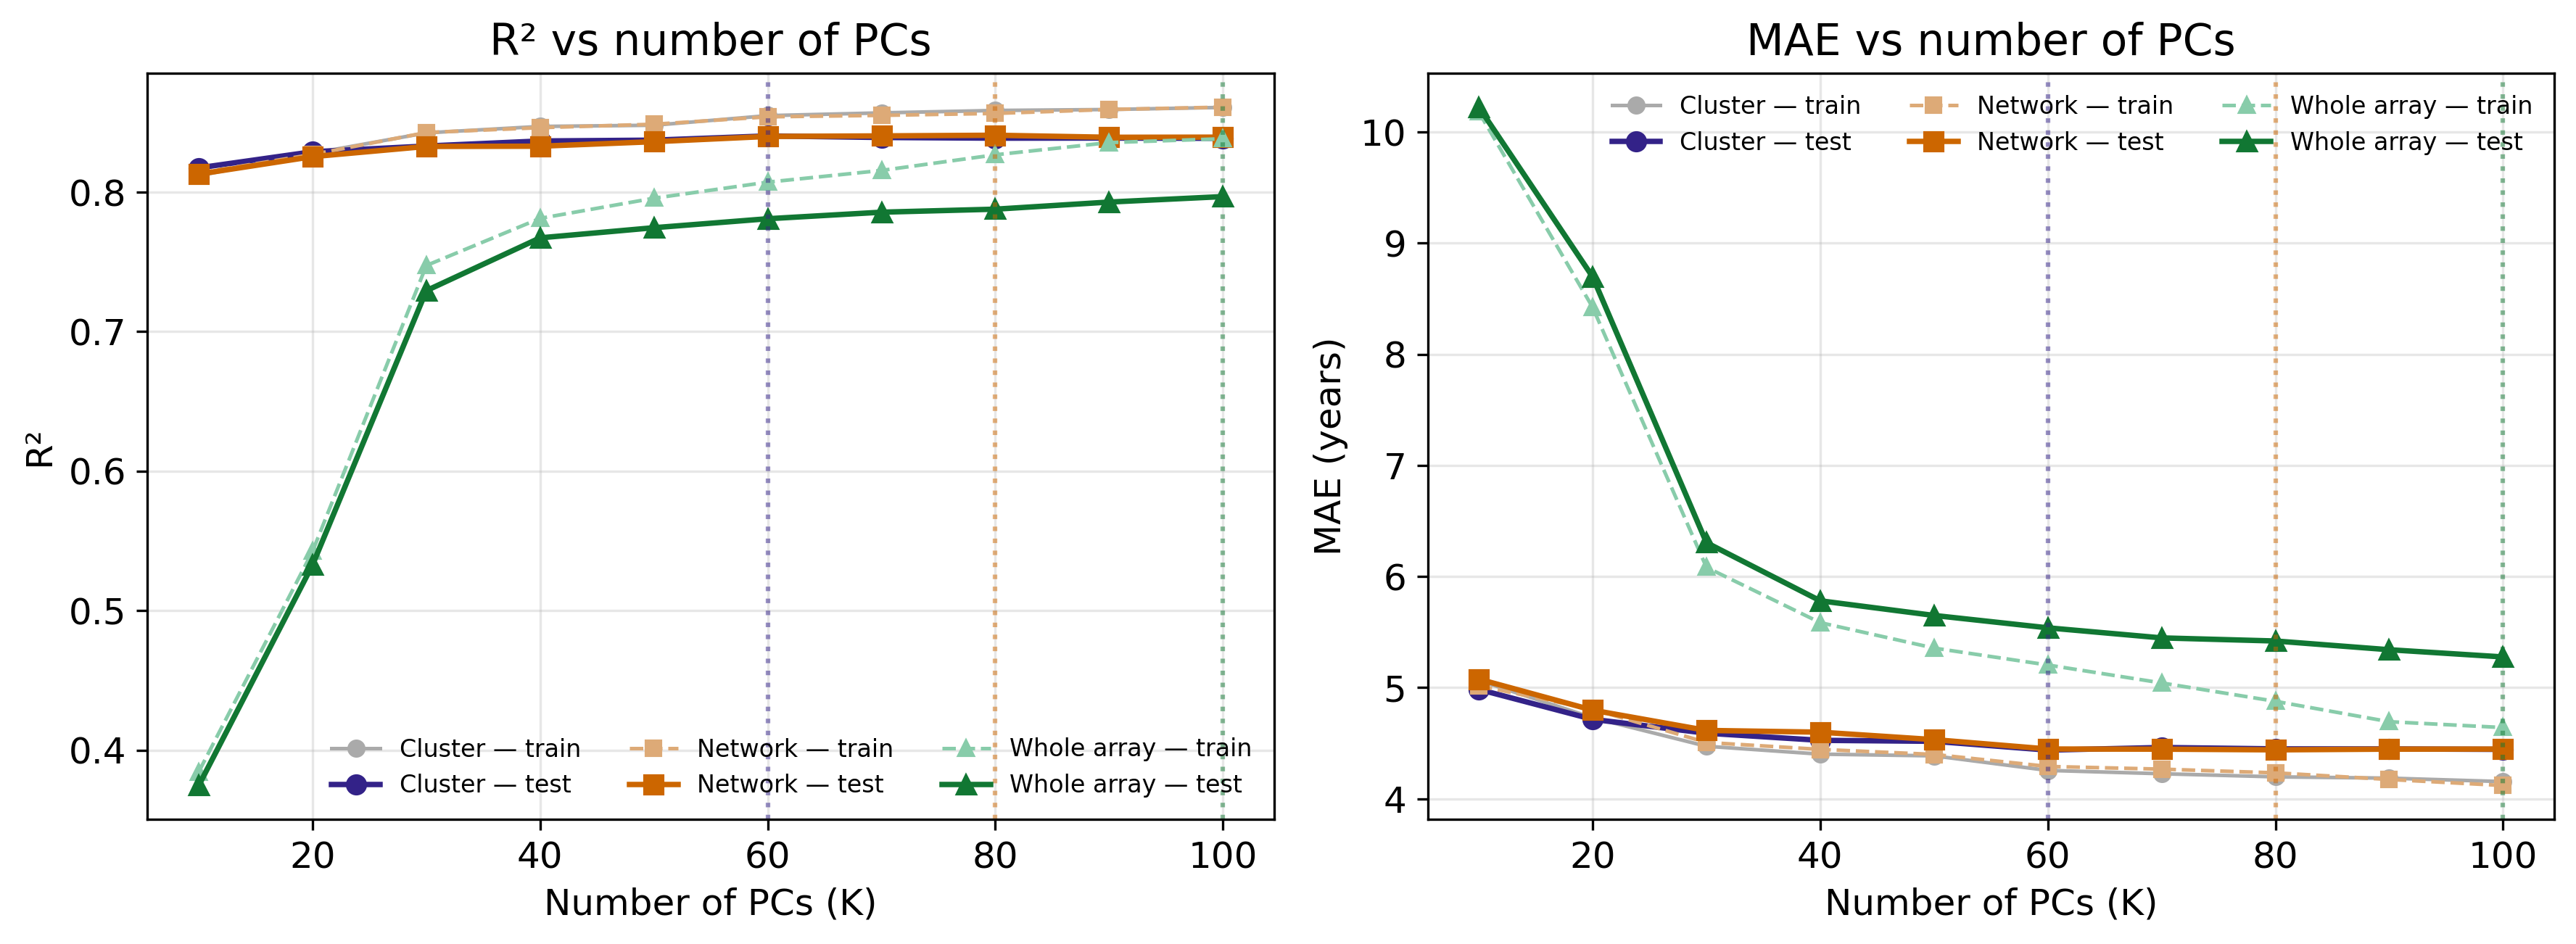


  Cluster PCA best:     K=60    R²_test=0.840  MAE_test=4.44y
  Network PCA best:     K=80    R²_test=0.841  MAE_test=4.44y
  Whole-array PCA best: K=100    R²_test=0.797  MAE_test=5.28y


In [11]:
# Overlay cluster PCA vs whole-network PCA vs whole-array PCA: train + test for each
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

def _overlay(ax, col_train, col_test, ylabel, legloc):
    ax.plot(df_sweep["K"],     df_sweep[col_train],     "o-",  color="#AAAAAA", lw=1.2, markersize=5, label="Cluster — train")
    ax.plot(df_sweep["K"],     df_sweep[col_test],      "o-",  color="#332288", lw=1.8, markersize=6, label="Cluster — test")
    ax.plot(df_sweep_net["K"], df_sweep_net[col_train], "s--", color="#DDAA77", lw=1.2, markersize=5, label="Network — train")
    ax.plot(df_sweep_net["K"], df_sweep_net[col_test],  "s-",  color="#CC6600", lw=1.8, markersize=6, label="Network — test")
    ax.plot(df_sweep_arr["K"], df_sweep_arr[col_train], "^--", color="#88CCAA", lw=1.2, markersize=5, label="Whole array — train")
    ax.plot(df_sweep_arr["K"], df_sweep_arr[col_test],  "^-",  color="#117733", lw=1.8, markersize=6, label="Whole array — test")
    ax.axvline(best_K,     color="#332288", ls=":", alpha=0.5)
    ax.axvline(best_K_net, color="#CC6600", ls=":", alpha=0.5)
    ax.axvline(best_K_arr, color="#117733", ls=":", alpha=0.5)
    ax.set_xlabel("Number of PCs (K)"); ax.set_ylabel(ylabel)
    ax.legend(frameon=False, fontsize=8, ncol=3, loc=legloc)
    ax.grid(True, alpha=0.3)

_overlay(axes[0], "r2_train", "r2_test", "R²", "lower right")
axes[0].set_title("R² vs number of PCs")
_overlay(axes[1], "mae_train", "mae_test", "MAE (years)", "upper right")
axes[1].set_title("MAE vs number of PCs")

fig.tight_layout()
_save(fig, OUT_DIR / "sweep_r2_mae_cluster_vs_network_vs_array.png")
plt.show()

print(f"\n  Cluster PCA best:     K={best_K}    R²_test={clock_by_K[best_K]['r2_test']:.3f}  MAE_test={clock_by_K[best_K]['mae_test']:.2f}y")
print(f"  Network PCA best:     K={best_K_net}    R²_test={clock_by_K_net[best_K_net]['r2_test']:.3f}  MAE_test={clock_by_K_net[best_K_net]['mae_test']:.2f}y")
print(f"  Whole-array PCA best: K={best_K_arr}    R²_test={clock_by_K_arr[best_K_arr]['r2_test']:.3f}  MAE_test={clock_by_K_arr[best_K_arr]['mae_test']:.2f}y")


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  -> outputs/05_pca_clock/scatter_best_K60.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

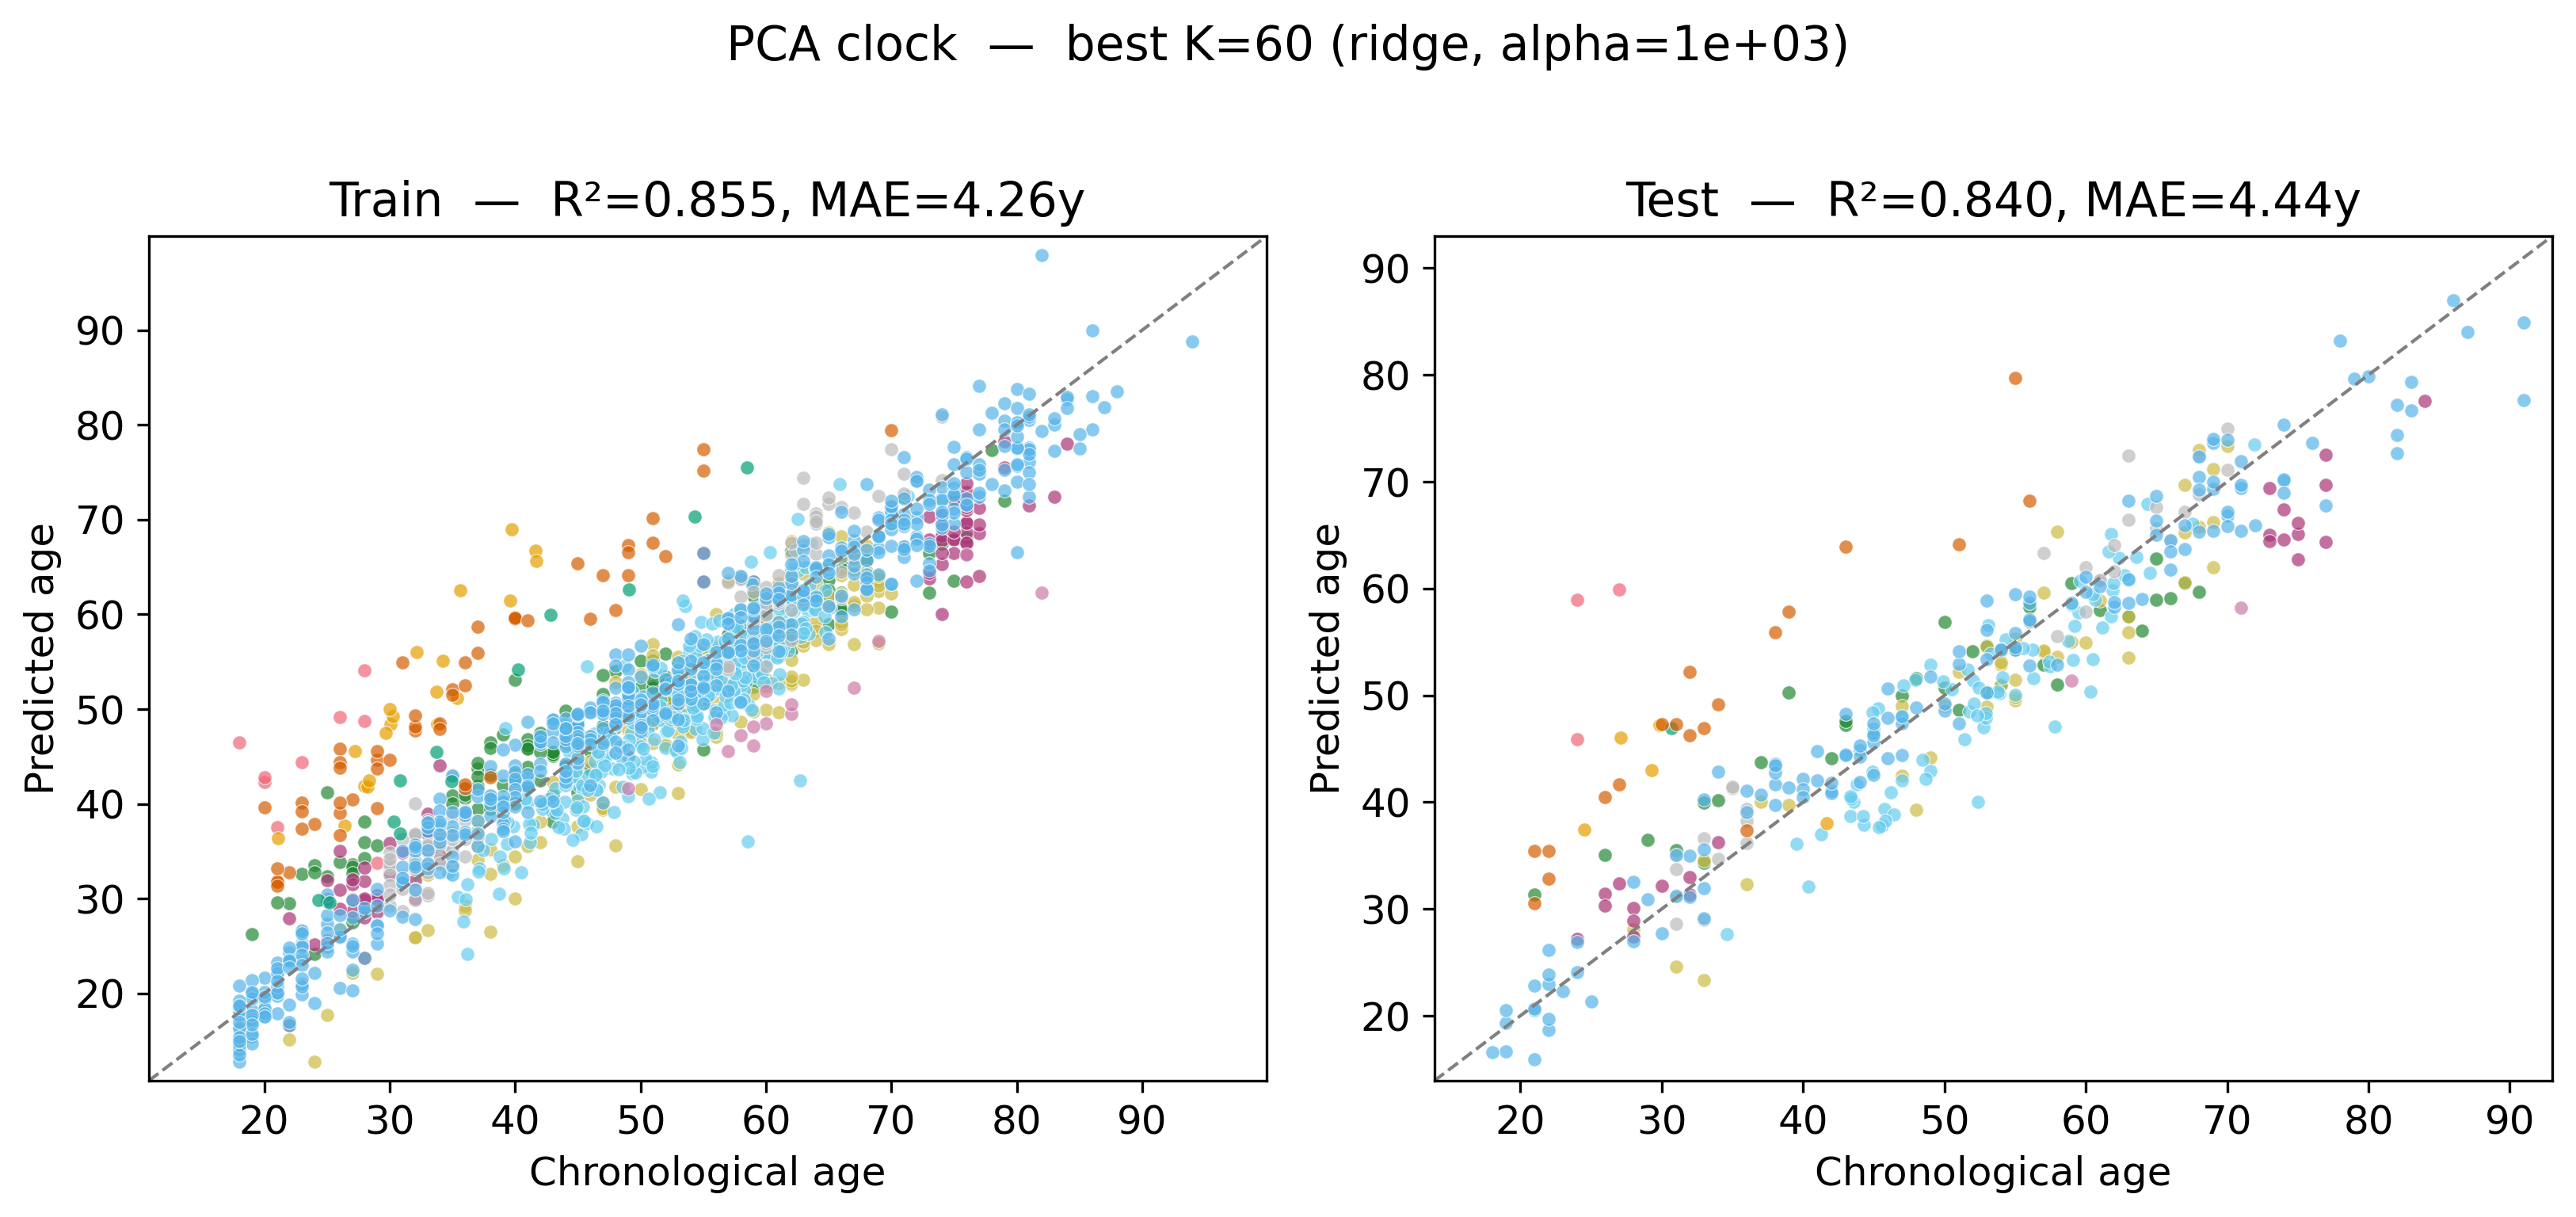

In [12]:
# Predicted vs chronological age for the best clock — train + test, coloured by study
best = clock_by_K[best_K]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (split, y_true, y_pred, sids_split) in zip(
    axes,
    [("Train", best["y_train"], best["pred_train"], best["studies_train"]),
     ("Test",  best["y_test"],  best["pred_test"],  best["studies_test"])]):
    studies_unique = sorted(set(sids_split))
    color_map = {s: STUDY_PALETTE[i % len(STUDY_PALETTE)] for i, s in enumerate(studies_unique)}
    for s in studies_unique:
        mask = sids_split == s
        ax.scatter(y_true[mask], y_pred[mask], s=18, alpha=0.7,
                   color=color_map[s], label=s, edgecolor="white", linewidth=0.3)
    lims = [min(y_true.min(), y_pred.min()) - 2, max(y_true.max(), y_pred.max()) + 2]
    ax.plot(lims, lims, "--", color="grey", linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    r2  = r2_score(y_true, y_pred); mae = mean_absolute_error(y_true, y_pred)
    ax.set_xlabel("Chronological age"); ax.set_ylabel("Predicted age")
    ax.set_title(f"{split}  —  R²={r2:.3f}, MAE={mae:.2f}y")
    if len(studies_unique) <= 8:
        ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle(f"PCA clock  —  best K={best_K} "
             f"({best['model_type']}, alpha={best['alpha']:.3g})", y=1.02)
fig.tight_layout()
_save(fig, OUT_DIR / f"scatter_best_K{best_K}.png")
plt.show()


## 7. Save a portable PCA clock

`pca_clock.pkl` contains **everything** needed to apply this clock to a new methylation dataset — the same role as `best_clocks_*.pkl` in `05_network_clock_v2.ipynb`, but expanded for the cluster → PCA → regression pipeline.

**Contents:**
- `cluster_definitions[cid] = {"cpgs": [...], "strategy": "singleton"|"mean"}` — how to compute each cluster variable from raw CpG data
- `cluster_order` — column order of the Sample × Cluster matrix (matches the PCA input)
- `scaler_mean` / `scaler_scale` — StandardScaler params on the training fold
- `pca_components` — PCA loading matrix `(n_comp, n_clusters)`
- `pca_mean` — PCA's centring (≈ 0 since we standardised first)
- `clock_by_K[K] = {"pc_coefs": ..., "intercept": ..., metrics, predictions, ...}` — one regression per K, including the **PC weights** for each clock
- `best_K` — K with highest test R²

In [13]:
cluster_order = list(X_clusters.columns)

full_clock = {
    "clock_kind":                "pca_cluster",
    # How to build the cluster matrix from raw CpG data
    "cluster_definitions":       cluster_strategy,
    "cluster_order":             cluster_order,
    # Standardisation (training-fold params)
    "scaler_mean":               sc.mean_.copy(),
    "scaler_scale":              sc.scale_.copy(),
    # PCA
    "pca_components":            pca.components_.copy(),
    "pca_mean":                  pca.mean_.copy(),
    "explained_variance_ratio":  pca.explained_variance_ratio_.copy(),
    # Regressions per K (each is a complete sub-clock: PC weights + intercept + metrics)
    "clock_by_K":                clock_by_K,
    "best_K":                    best_K,
    # Reproducibility metadata
    "config": {
        "BIG_CLUSTER_THRESHOLD": BIG_CLUSTER_THRESHOLD,
        "SKEW_MAX":              SKEW_MAX,
        "EXCESS_KURT_MIN":       EXCESS_KURT_MIN,
        "EXCESS_KURT_MAX":       EXCESS_KURT_MAX,
        "BIMODALITY_MAX":        BIMODALITY_MAX,
        "TEST_FRACTION":         TEST_FRACTION,
        "SEED":                  SEED,
        "USE_RIDGE":             USE_RIDGE,
        "PC_COUNTS_TO_TEST":     PC_COUNTS_TO_TEST,
    },
}

save_path = SAVED_CLOCKS_DIR / "pca_clock.pkl"
with open(save_path, "wb") as f:
    pickle.dump(full_clock, f)
print(f"  Saved full PCA clock → {save_path}")

# Compact summary CSV (same column shape as 05's all_modes_summary.csv)
summary_rows = []
for K, c in clock_by_K.items():
    summary_rows.append({
        "clock":      f"PCA-{c['model_type']} (K={K})",
        "k_pcs":      K,
        "model_type": c["model_type"],
        "alpha":      c["alpha"],
        "r2_test":    c["r2_test"],
        "mae_test":   c["mae_test"],
        "medae_test": c["medae_test"],
        "n_train":    len(c["y_train"]),
        "n_test":     len(c["y_test"]),
    })
pd.DataFrame(summary_rows).to_csv(OUT_DIR / "pca_clock_summary.csv", index=False)
print(f"  Saved summary CSV → {OUT_DIR / 'pca_clock_summary.csv'}")


  Saved full PCA clock → outputs/05_pca_clock/saved_clocks/pca_clock.pkl
  Saved summary CSV → outputs/05_pca_clock/pca_clock_summary.csv


## 7b. Save the network-baseline PCA clock

Same idea as Section 7, parallel pickle for the whole-network PCA clock. Used by the test notebook to evaluate both clocks on the unseen cohorts.

In [14]:
network_clock = {
    "clock_kind":                "pca_network",
    # Feature list — the full CpG order used at training, column order of the PCA input
    "cpg_order":                 all_network_cpgs,
    # Standardisation (training-fold params)
    "scaler_mean":               sc_net.mean_.copy(),
    "scaler_scale":              sc_net.scale_.copy(),
    # PCA
    "pca_components":            pca_net.components_.copy(),
    "pca_mean":                  pca_net.mean_.copy(),
    "explained_variance_ratio":  pca_net.explained_variance_ratio_.copy(),
    # Per-K sub-clocks
    "clock_by_K":                clock_by_K_net,
    "best_K":                    best_K_net,
    "config": {
        "TEST_FRACTION":      TEST_FRACTION,
        "SEED":               SEED,
        "USE_RIDGE":          USE_RIDGE,
        "PC_COUNTS_TO_TEST":  PC_COUNTS_TO_TEST,
        "RIDGE_ALPHAS_RANGE": [float(RIDGE_ALPHAS.min()), float(RIDGE_ALPHAS.max())],
        "RIDGE_CV_FOLDS":     RIDGE_CV_FOLDS,
    },
}

save_path_net = SAVED_CLOCKS_DIR / "pca_network_clock.pkl"
with open(save_path_net, "wb") as f:
    pickle.dump(network_clock, f)
print(f"  Saved network-baseline PCA clock → {save_path_net}")

summary_rows_net = []
for K, c in clock_by_K_net.items():
    summary_rows_net.append({
        "clock":      f"PCA-network-{c['model_type']} (K={K})",
        "k_pcs":      K, "model_type": c["model_type"], "alpha": c["alpha"],
        "r2_test":    c["r2_test"], "mae_test": c["mae_test"], "medae_test": c["medae_test"],
        "n_train":    len(c["y_train"]), "n_test": len(c["y_test"]),
    })
pd.DataFrame(summary_rows_net).to_csv(OUT_DIR / "pca_network_clock_summary.csv", index=False)
print(f"  Saved network summary CSV → {OUT_DIR / 'pca_network_clock_summary.csv'}")


  Saved network-baseline PCA clock → outputs/05_pca_clock/saved_clocks/pca_network_clock.pkl
  Saved network summary CSV → outputs/05_pca_clock/pca_network_clock_summary.csv


## 7c. Save the whole-array PCA clock

Same portable structure as the network baseline (`cpg_order`-based), with `clock_kind="pca_array"`.

In [15]:
array_clock = {
    "clock_kind":                "pca_array",
    "cpg_order":                 all_array_cpgs,
    "scaler_mean":               sc_arr_mean.copy(),
    "scaler_scale":              sc_arr_scale.copy(),
    "pca_components":            pca_arr.components_.copy(),
    "pca_mean":                  pca_arr.mean_.copy(),
    "explained_variance_ratio":  pca_arr.explained_variance_ratio_.copy(),
    "clock_by_K":                clock_by_K_arr,
    "best_K":                    best_K_arr,
    "config": {
        "TEST_FRACTION":      TEST_FRACTION,
        "SEED":               SEED,
        "USE_RIDGE":          USE_RIDGE,
        "PC_COUNTS_TO_TEST":  PC_COUNTS_TO_TEST,
        "RIDGE_ALPHAS_RANGE": [float(RIDGE_ALPHAS.min()), float(RIDGE_ALPHAS.max())],
        "RIDGE_CV_FOLDS":     RIDGE_CV_FOLDS,
    },
}

save_path_arr = SAVED_CLOCKS_DIR / "pca_array_clock.pkl"
with open(save_path_arr, "wb") as f:
    pickle.dump(array_clock, f)
print(f"  Saved whole-array PCA clock → {save_path_arr}")

summary_rows_arr = []
for K, c in clock_by_K_arr.items():
    summary_rows_arr.append({
        "clock":      f"PCA-array-{c['model_type']} (K={K})",
        "k_pcs":      K, "model_type": c["model_type"], "alpha": c["alpha"],
        "r2_test":    c["r2_test"], "mae_test": c["mae_test"], "medae_test": c["medae_test"],
        "n_train":    len(c["y_train"]), "n_test": len(c["y_test"]),
    })
pd.DataFrame(summary_rows_arr).to_csv(OUT_DIR / "pca_array_clock_summary.csv", index=False)
print(f"  Saved whole-array summary CSV → {OUT_DIR / 'pca_array_clock_summary.csv'}")

# ── Recap: the three saved clocks for downstream testing ──
print("\n  Three PCA clocks saved for external testing:")
print(f"    1. cluster      → {SAVED_CLOCKS_DIR / 'pca_clock.pkl'}          "
      f"(K*={best_K},     R²_test={clock_by_K[best_K]['r2_test']:.3f})")
print(f"    2. whole-network→ {SAVED_CLOCKS_DIR / 'pca_network_clock.pkl'}  "
      f"(K*={best_K_net}, R²_test={clock_by_K_net[best_K_net]['r2_test']:.3f})")
print(f"    3. whole-array  → {SAVED_CLOCKS_DIR / 'pca_array_clock.pkl'}    "
      f"(K*={best_K_arr}, R²_test={clock_by_K_arr[best_K_arr]['r2_test']:.3f})")


  Saved whole-array PCA clock → outputs/05_pca_clock/saved_clocks/pca_array_clock.pkl
  Saved whole-array summary CSV → outputs/05_pca_clock/pca_array_clock_summary.csv

  Three PCA clocks saved for external testing:
    1. cluster      → outputs/05_pca_clock/saved_clocks/pca_clock.pkl          (K*=60,     R²_test=0.840)
    2. whole-network→ outputs/05_pca_clock/saved_clocks/pca_network_clock.pkl  (K*=80, R²_test=0.841)
    3. whole-array  → outputs/05_pca_clock/saved_clocks/pca_array_clock.pkl    (K*=100, R²_test=0.797)


## 8. Portable predictor — apply the clock to a new dataset

`predict_pca_clock(df_meth_new, clock, K=None)` mirrors the full training pipeline:

1. Rebuild the cluster-level matrix from new CpG data using `cluster_definitions` (singleton → CpG; mean → average across CpGs).
2. Fill any cluster column that's missing CpGs on the new dataset with the training mean (a defensive default; warn if many).
3. Standardise with the training `scaler_mean / scaler_scale`.
4. Project onto PCs using `pca_components` (and `pca_mean`).
5. Multiply the top-K PC scores by `pc_coefs` and add `intercept`.

The cell below also re-applies the saved best clock to the original data and verifies the output matches the stored predictions to numerical precision — a sanity check that the saved clock is faithfully portable.

In [16]:
def predict_pca_clock(df_meth_new, clock, K=None, verbose=True):
    """Apply a saved PCA clock dict to a new Sample × CpG methylation matrix.

    df_meth_new : pd.DataFrame, rows = samples, cols = CpGs (subset OK; missing
                  CpGs are tolerated — see warning logic below).
    clock       : full_clock dict (e.g. unpickled from pca_clock.pkl).
    K           : which top-K sub-clock to use (default = clock["best_K"]).

    Returns predictions as a 1-D np.ndarray, in df_meth_new row order.
    """
    cluster_order = clock["cluster_order"]
    defs          = clock["cluster_definitions"]
    if K is None:
        K = clock["best_K"]
    K_clock = clock["clock_by_K"][K]

    # 1. Rebuild cluster matrix in the SAME column order as training
    cols = {}
    missing_cpgs = 0; missing_clusters = 0
    for cid in cluster_order:
        cpgs  = defs[cid]["cpgs"]
        strat = defs[cid]["strategy"]
        present = [c for c in cpgs if c in df_meth_new.columns]
        missing_cpgs += (len(cpgs) - len(present))
        if not present:
            missing_clusters += 1
            cols[cid] = pd.Series(np.nan, index=df_meth_new.index)
            continue
        if strat == "singleton":
            cols[cid] = df_meth_new[present[0]]
        elif strat == "median":
            cols[cid] = df_meth_new[present].median(axis=1)
        elif strat == "mean":      # backward compat with older pickles
            cols[cid] = df_meth_new[present].mean(axis=1)
        else:
            raise ValueError(f"unknown cluster strategy '{strat}' for cluster {cid}")
    X_new = pd.DataFrame(cols)[cluster_order]
    if verbose and missing_cpgs:
        print(f"  predict_pca_clock: {missing_cpgs} CpGs missing across all clusters")
    if verbose and missing_clusters:
        print(f"  predict_pca_clock: {missing_clusters} clusters entirely missing — filled with training mean")

    # 2. Fill NaN (per-cluster) with training mean
    mean = clock["scaler_mean"]; scale = clock["scaler_scale"]
    for j, cid in enumerate(cluster_order):
        col = X_new[cid]
        if col.isna().any():
            X_new[cid] = col.fillna(mean[j])
    X_new_arr = X_new.values

    # 3. Standardise with training params
    X_new_s = (X_new_arr - mean) / scale

    # 4. Project to PC space
    V        = clock["pca_components"]        # (n_comp, n_clusters)
    pca_mean = clock["pca_mean"]
    Z        = (X_new_s - pca_mean) @ V.T     # (n_samples, n_comp)

    # 5. Top-K PC scores → linear prediction
    Z_K = Z[:, :K]
    return Z_K @ K_clock["pc_coefs"] + K_clock["intercept"]


# Sanity check: re-apply on the original df_meth, compare to stored predictions
y_pred_all = predict_pca_clock(df_meth.loc[X_clusters.index], full_clock,
                                K=best_K, verbose=False)
delta_tr = float(np.max(np.abs(y_pred_all[i_tr] - clock_by_K[best_K]["pred_train"])))
delta_te = float(np.max(np.abs(y_pred_all[i_te] - clock_by_K[best_K]["pred_test"])))
print(f"  Sanity train: max |Δ| = {delta_tr:.2e}")
print(f"  Sanity test:  max |Δ| = {delta_te:.2e}")
print("  Both should be ≪ 1e-6 — confirms the saved clock is faithfully portable.")


  Sanity train: max |Δ| = 2.70e-13
  Sanity test:  max |Δ| = 2.84e-14
  Both should be ≪ 1e-6 — confirms the saved clock is faithfully portable.


## 8b. Portable predictor for the network-baseline clock

Same shape as `predict_pca_clock` but skips the cluster-construction step: the input matrix is just `df_meth_new[cpg_order]`, missing CpGs are filled with the training mean, then standardise → project onto saved PC axes → take top-$K$ → multiply by saved ridge weights.

In [17]:
def predict_pca_network_clock(df_meth_new, clock, K=None, verbose=True):
    """Apply a saved network-baseline PCA clock to a new Sample × CpG matrix.

    df_meth_new : DataFrame, rows = samples, cols = CpGs (subset OK; missing CpGs
                  are filled with the training mean).
    clock       : network_clock dict from this notebook (clock_kind='pca_network').
    K           : which top-K sub-clock to use (default = clock['best_K']).

    Returns predictions as a 1-D np.ndarray, in df_meth_new row order.
    """
    cpg_order = clock["cpg_order"]
    if K is None:
        K = clock["best_K"]
    K_clock = clock["clock_by_K"][K]

    mean  = clock["scaler_mean"]
    scale = clock["scaler_scale"]

    # 1. Pull CpG columns in training order; fill missing CpGs with training mean
    present_mask = np.array([c in df_meth_new.columns for c in cpg_order])
    n_missing = int((~present_mask).sum())
    if verbose and n_missing:
        print(f"  predict_pca_network_clock: {n_missing} CpGs missing — filled with training mean")

    X_new = np.empty((df_meth_new.shape[0], len(cpg_order)), dtype=float)
    present_cpgs = [c for c, p in zip(cpg_order, present_mask) if p]
    if present_cpgs:
        X_new[:, present_mask] = df_meth_new[present_cpgs].values
    if n_missing:
        X_new[:, ~present_mask] = mean[~present_mask]

    # NaN within a present CpG → training mean for that CpG
    if np.isnan(X_new).any():
        col_idx = np.where(np.isnan(X_new).any(axis=0))[0]
        for j in col_idx:
            col = X_new[:, j]
            col[np.isnan(col)] = mean[j]
            X_new[:, j] = col

    # 2. Standardise with training params
    X_new_s = (X_new - mean) / np.where(scale > 0, scale, 1.0)

    # 3. Project onto saved PC axes
    V        = clock["pca_components"]
    pca_mean = clock["pca_mean"]
    Z        = (X_new_s - pca_mean) @ V.T

    # 4. Top-K PC scores → ridge prediction
    return Z[:, :K] @ K_clock["pc_coefs"] + K_clock["intercept"]


# Sanity: re-apply on the same training matrix, confirm bit-faithful predictions
y_pred_all_net = predict_pca_network_clock(df_meth.loc[X_clusters.index], network_clock,
                                            K=best_K_net, verbose=False)
delta_tr_net = float(np.max(np.abs(y_pred_all_net[i_tr] - clock_by_K_net[best_K_net]["pred_train"])))
delta_te_net = float(np.max(np.abs(y_pred_all_net[i_te] - clock_by_K_net[best_K_net]["pred_test"])))
print(f"  Sanity train: max |Δ| = {delta_tr_net:.2e}")
print(f"  Sanity test:  max |Δ| = {delta_te_net:.2e}")
print("  Both should be ≪ 1e-6 — network clock is faithfully portable.")


  Sanity train: max |Δ| = 3.13e-13
  Sanity test:  max |Δ| = 1.42e-14
  Both should be ≪ 1e-6 — network clock is faithfully portable.


## 8c. Predictor for the whole-array clock

The whole-array and whole-network clocks share the same portable structure (`cpg_order` + scaler + PCA loadings + per-K ridge), so the same function applies to both. We just alias it for clarity and run a faithfulness check on the array clock.

In [18]:
# The cpg_order-based predictor is generic — reuse it for the whole-array clock.
predict_pca_array_clock = predict_pca_network_clock

# Sanity: re-apply on the training matrix, confirm bit-faithful predictions
y_pred_all_arr = predict_pca_array_clock(df_meth.loc[X_clusters.index], array_clock,
                                         K=best_K_arr, verbose=False)
delta_tr_arr = float(np.max(np.abs(y_pred_all_arr[i_tr] - clock_by_K_arr[best_K_arr]["pred_train"])))
delta_te_arr = float(np.max(np.abs(y_pred_all_arr[i_te] - clock_by_K_arr[best_K_arr]["pred_test"])))
print(f"  Sanity train: max |Δ| = {delta_tr_arr:.2e}")
print(f"  Sanity test:  max |Δ| = {delta_te_arr:.2e}")
print("  Both should be ≪ 1e-6 — whole-array clock is faithfully portable.")


  Sanity train: max |Δ| = 3.84e+01
  Sanity test:  max |Δ| = 2.89e+01
  Both should be ≪ 1e-6 — whole-array clock is faithfully portable.
